In [ ]:
import os
import cv2
import glob
import numpy as np
import mediapipe as mp
from tqdm import tqdm
import pickle
import torch
import os

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from torchvision import models
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
from PIL import Image

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns




2025-12-17 01:13:59.169403: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-17 01:13:59.480287: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-17 01:13:59.480448: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-17 01:13:59.528042: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-17 01:13:59.645305: I tensorflow/core/platform/cpu_feature_guar

In [ ]:

class Graph:
    def __init__(self, strategy='spatial'):
        self.num_node = 33
        self.get_edge()
        self.A = self.get_adjacency_matrix()

    def get_edge(self):
        # MediaPipe Full Body Topology (0-32)
        self.num_node = 33
        self_link = [(i, i) for i in range(self.num_node)]
        neighbor_link = [
            (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8), 
            (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), 
            (17, 19), (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20), 
            (11, 23), (12, 24), (23, 24), (23, 25), (24, 26), (25, 27), (26, 28), 
            (27, 29), (28, 30), (29, 31), (30, 32), (27, 31), (28, 32)
        ]
        self.edge = self_link + neighbor_link
        self.center = 0

    def get_adjacency_matrix(self):
        A = np.zeros((self.num_node, self.num_node))
        for i, j in self.edge:
            A[j, i] = 1
            A[i, j] = 1
        
        # Normalize Adjacency
        Dl = np.sum(A, 0)
        num_node = A.shape[0]
        Dn = np.zeros((num_node, num_node))
        for i in range(num_node):
            if Dl[i] > 0:
                Dn[i, i] = Dl[i]**(-0.5)
        DAD = np.dot(np.dot(Dn, A), Dn)
        return torch.tensor(DAD, dtype=torch.float32)

In [ ]:


# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Point this to the ROOT folder where you saved the 'train' and 'val' folders of .npy files
SKELETON_ROOT = '/mnt/e/SignProject/Skeleton based/skeletons' 
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.1 

# ---------------- 1. DATASET ----------------
class SkeletonDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.split_dir = os.path.join(root_dir, split)
        self.classes = sorted(os.listdir(self.split_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []
        
        print(f"Scanning {split} data...")
        for cls in self.classes:
            cls_folder = os.path.join(self.split_dir, cls)
            if not os.path.isdir(cls_folder): continue
            
            # Find all .npy files
            files = sorted(glob.glob(os.path.join(cls_folder, "*.npy")))
            for f in files:
                self.samples.append((f, self.class_to_idx[cls]))
                
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        
        # Load Raw: (T, V, C) -> (32, 33, 3)
        data = np.load(path)
        
        # 1. Transpose to (C, T, V) -> (3, 32, 33)
        data = data.transpose(2, 0, 1)
        
        # 2. Add Person Dimension -> (C, T, V, M) -> (3, 32, 33, 1)
        data = np.expand_dims(data, axis=-1)
        
        # Convert to Tensor
        return torch.tensor(data, dtype=torch.float32), label

# ---------------- 2. MODEL DEFINITION ----------------
# (Uses the Graph class defined above)
class CTRGC(nn.Module):
    def __init__(self, in_channels, out_channels, rel_reduction=8):
        super(CTRGC, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        if in_channels <= 16: self.rel_channels = 8
        else: self.rel_channels = in_channels // rel_reduction
        
        self.conv1 = nn.Conv2d(self.in_channels, self.rel_channels, kernel_size=1)
        self.conv2 = nn.Conv2d(self.in_channels, self.rel_channels, kernel_size=1)
        self.conv3 = nn.Conv2d(self.in_channels, self.out_channels, kernel_size=1)
        self.conv4 = nn.Conv2d(self.rel_channels, self.out_channels, kernel_size=1)
        self.tanh = nn.Tanh()
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, x, A):
        # x: (N, C, T, V)
        N, C, T, V = x.size()
        x1 = self.conv1(x).mean(-2) 
        x2 = self.conv2(x).mean(-2) 
        x1 = self.tanh(x1.unsqueeze(-1) - x2.unsqueeze(-2))
        x1 = self.conv4(x1).permute(0, 2, 3, 1).contiguous()
        x3 = self.conv3(x)
        x3 = x3.permute(0, 3, 2, 1).contiguous().view(N, V, T*self.out_channels)
        out = torch.matmul(A.to(x.device), x3)
        out = out.view(N, V, T, self.out_channels).permute(0, 3, 2, 1)
        out = out + x3.view(N, V, T, self.out_channels).permute(0, 3, 2, 1)
        return out

class Block(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, residual=True):
        super(Block, self).__init__()
        self.gcn = CTRGC(in_channels, out_channels)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=(9,1), padding=(4,0), stride=(stride,1)),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(0.1, inplace=True)
        )
        if not residual: self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1): self.residual = lambda x: x
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride,1)),
                nn.BatchNorm2d(out_channels)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, A):
        res = self.residual(x)
        x = self.gcn(x, A)
        x = self.tcn(x)
        return self.relu(x + res)

# ---------------- FULL MODEL (CORRECTED) ----------------
class CTRGCN(nn.Module):
    def __init__(self, num_class, in_channels=3):
        super(CTRGCN, self).__init__()
        self.graph = Graph()
        A = self.graph.A
        self.register_buffer('A', A)
        
        self.data_bn = nn.BatchNorm1d(in_channels * 33) # 33 joints
        
        # Layers: (In, Out, Stride)
        self.l1 = Block(3, 64, stride=1)
        self.l2 = Block(64, 64, stride=1)
        self.l3 = Block(64, 64, stride=1)
        self.l4 = Block(64, 128, stride=2) # Downsamples T
        self.l5 = Block(128, 128, stride=1)
        self.l6 = Block(128, 128, stride=1)
        self.l7 = Block(128, 256, stride=2) # Downsamples T
        self.l8 = Block(256, 256, stride=1)
        self.l9 = Block(256, 256, stride=1)
        self.l10 = Block(256, 256, stride=1)
        
        self.fc = nn.Linear(256, num_class)

    def forward(self, x):
        # x: (N, C, T, V, M)
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous().view(N, M*V*C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T).permute(0, 1, 3, 4, 2).contiguous().view(N * M, C, T, V)
        
        x = self.l1(x, self.A)
        x = self.l2(x, self.A)
        x = self.l3(x, self.A)
        x = self.l4(x, self.A)
        x = self.l5(x, self.A)
        x = self.l6(x, self.A)
        x = self.l7(x, self.A)
        x = self.l8(x, self.A)
        x = self.l9(x, self.A)
        x = self.l10(x, self.A)
        
        # --- FIX IS HERE ---
        # Old (Broken): x = x.view(N, M, 256, T, V).mean(4).mean(3)
        # New (Correct): Use -1 to let PyTorch determine the new temporal size (e.g., 8)
        x = x.view(N, M, 256, -1, V).mean(4).mean(3) 
        
        x = x.mean(1) # Mean over M (Persons)
        return self.fc(x)

# ---------------- 3. MAIN LOOP ----------------
def main():
    print(f"Using device: {DEVICE}")
    
    # Init Datasets
    train_dataset = SkeletonDataset(root_dir=SKELETON_ROOT, split='train')
    val_dataset = SkeletonDataset(root_dir=SKELETON_ROOT, split='val')
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    print(f"Classes: {train_dataset.classes}")
    
    model = CTRGCN(num_class=len(train_dataset.classes)).to(DEVICE)
    
    # CTR-GCN training specifics
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0004)
    # Warmup + Cosine Schedule
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    best_acc = 0.0

    for epoch in range(1, EPOCHS+1):
        model.train()
        train_loss, correct, total = 0, 0, 0
        loop = tqdm(train_loader, desc=f"Ep {epoch}/{EPOCHS}")
        
        for x, y in loop:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, preds = torch.max(logits, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            loop.set_postfix(loss=loss.item())
            
        train_acc = correct / total
        
        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                _, preds = torch.max(logits, 1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                
        val_acc = val_correct / val_total
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        
        if val_acc > best_acc:
            print(f"New Best ({val_acc:.4f})! Saving...")
            best_acc = val_acc
            torch.save(model.state_dict(), "best_ctr_gcn.pth")
            
        scheduler.step()

# --- HELPER GRAPH CLASS (Paste this BEFORE main code) ---
class Graph:
    def __init__(self, strategy='spatial'):
        self.num_node = 33
        self.get_edge()
        self.A = self.get_adjacency_matrix()

    def get_edge(self):
        # MediaPipe Connections (0-32)
        self.num_node = 33
        self_link = [(i, i) for i in range(self.num_node)]
        neighbor_link = [
            (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8), 
            (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), 
            (17, 19), (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20), 
            (11, 23), (12, 24), (23, 24), (23, 25), (24, 26), (25, 27), (26, 28), 
            (27, 29), (28, 30), (29, 31), (30, 32), (27, 31), (28, 32)
        ]
        self.edge = self_link + neighbor_link
        self.center = 0

    def get_adjacency_matrix(self):
        A = np.zeros((self.num_node, self.num_node))
        for i, j in self.edge:
            A[j, i] = 1
            A[i, j] = 1
        Dl = np.sum(A, 0)
        num_node = A.shape[0]
        Dn = np.zeros((num_node, num_node))
        for i in range(num_node):
            if Dl[i] > 0: Dn[i, i] = Dl[i]**(-0.5)
        DAD = np.dot(np.dot(Dn, A), Dn)
        return torch.tensor(DAD, dtype=torch.float32)

if __name__ == "__main__":
    main()

Using device: cuda
Scanning train data...
Scanning val data...
Classes: ['Accident', 'Dangerous', 'Dead', 'Difficult', 'Dizzy', 'I am Scared', 'Violent']


Ep 1/100: 100%|██████████| 139/139 [00:16<00:00,  8.43it/s, loss=1.8] 


Train Acc: 0.1628 | Val Acc: 0.2686
New Best (0.2686)! Saving...


Ep 2/100: 100%|██████████| 139/139 [00:04<00:00, 31.09it/s, loss=1.83]


Train Acc: 0.2338 | Val Acc: 0.2788
New Best (0.2788)! Saving...


...

Train Acc: 1.0000 | Val Acc: 0.8117


Ep 99/100: 100%|██████████| 139/139 [00:04<00:00, 28.81it/s, loss=0.449]


Train Acc: 0.9998 | Val Acc: 0.7942


Ep 100/100: 100%|██████████| 139/139 [00:04<00:00, 29.97it/s, loss=0.45] 


Train Acc: 1.0000 | Val Acc: 0.8088


In [ ]:


# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# PATHS (Verify these are correct on your machine)
SWIN_PATH = "/mnt/e/SignProject/SLR-Transformer/best_slr_swin_finetuned.pth"                     # Your 93.43% Swin Model
GCN_PATH = "/mnt/e/SignProject/Skeleton based/best_ctr_gcn.pth"                       # Your 86% Skeleton Model
RGB_ROOT = '/mnt/e/SignProject/R(2+1)D /R(2+1)D/frames_r21d' # Path to images
SKELETON_ROOT = '/mnt/e/SignProject/Skeleton based/skeletons'                   # Path to .npy files

BATCH_SIZE = 1 # Inference one-by-one is safer for fusion analysis

# =============================================================================
# 1. SKELETON MODEL DEFINITIONS (CTRGCN)
# =============================================================================

class Graph:
    def __init__(self, strategy='spatial'):
        self.num_node = 33
        self.get_edge()
        self.A = self.get_adjacency_matrix()

    def get_edge(self):
        self.num_node = 33
        self_link = [(i, i) for i in range(self.num_node)]
        neighbor_link = [
            (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8), 
            (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), 
            (17, 19), (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20), 
            (11, 23), (12, 24), (23, 24), (23, 25), (24, 26), (25, 27), (26, 28), 
            (27, 29), (28, 30), (29, 31), (30, 32), (27, 31), (28, 32)
        ]
        self.edge = self_link + neighbor_link
        self.center = 0

    def get_adjacency_matrix(self):
        A = np.zeros((self.num_node, self.num_node))
        for i, j in self.edge:
            A[j, i] = 1
            A[i, j] = 1
        Dl = np.sum(A, 0)
        num_node = A.shape[0]
        Dn = np.zeros((num_node, num_node))
        for i in range(num_node):
            if Dl[i] > 0: Dn[i, i] = Dl[i]**(-0.5)
        DAD = np.dot(np.dot(Dn, A), Dn)
        return torch.tensor(DAD, dtype=torch.float32)

class CTRGC(nn.Module):
    def __init__(self, in_channels, out_channels, rel_reduction=8):
        super(CTRGC, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        if in_channels <= 16: self.rel_channels = 8
        else: self.rel_channels = in_channels // rel_reduction
        
        self.conv1 = nn.Conv2d(self.in_channels, self.rel_channels, kernel_size=1)
        self.conv2 = nn.Conv2d(self.in_channels, self.rel_channels, kernel_size=1)
        self.conv3 = nn.Conv2d(self.in_channels, self.out_channels, kernel_size=1)
        self.conv4 = nn.Conv2d(self.rel_channels, self.out_channels, kernel_size=1)
        self.tanh = nn.Tanh()

    def forward(self, x, A):
        N, C, T, V = x.size()
        x1 = self.conv1(x).mean(-2) 
        x2 = self.conv2(x).mean(-2) 
        x1 = self.tanh(x1.unsqueeze(-1) - x2.unsqueeze(-2))
        x1 = self.conv4(x1).permute(0, 2, 3, 1).contiguous()
        x3 = self.conv3(x)
        x3 = x3.permute(0, 3, 2, 1).contiguous().view(N, V, T*self.out_channels)
        out = torch.matmul(A.to(x.device), x3)
        out = out.view(N, V, T, self.out_channels).permute(0, 3, 2, 1)
        out = out + x3.view(N, V, T, self.out_channels).permute(0, 3, 2, 1)
        return out

class Block(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, residual=True):
        super(Block, self).__init__()
        self.gcn = CTRGC(in_channels, out_channels)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=(9,1), padding=(4,0), stride=(stride,1)),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(0.1, inplace=True)
        )
        if not residual: self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1): self.residual = lambda x: x
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride,1)),
                nn.BatchNorm2d(out_channels)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, A):
        res = self.residual(x)
        x = self.gcn(x, A)
        x = self.tcn(x)
        return self.relu(x + res)

class CTRGCN(nn.Module):
    def __init__(self, num_class, in_channels=3):
        super(CTRGCN, self).__init__()
        self.graph = Graph()
        A = self.graph.A
        self.register_buffer('A', A)
        
        self.data_bn = nn.BatchNorm1d(in_channels * 33)
        self.l1 = Block(3, 64, stride=1)
        self.l2 = Block(64, 64, stride=1)
        self.l3 = Block(64, 64, stride=1)
        self.l4 = Block(64, 128, stride=2)
        self.l5 = Block(128, 128, stride=1)
        self.l6 = Block(128, 128, stride=1)
        self.l7 = Block(128, 256, stride=2)
        self.l8 = Block(256, 256, stride=1)
        self.l9 = Block(256, 256, stride=1)
        self.l10 = Block(256, 256, stride=1)
        self.fc = nn.Linear(256, num_class)

    def forward(self, x):
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous().view(N, M*V*C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T).permute(0, 1, 3, 4, 2).contiguous().view(N * M, C, T, V)
        x = self.l1(x, self.A)
        x = self.l2(x, self.A)
        x = self.l3(x, self.A)
        x = self.l4(x, self.A)
        x = self.l5(x, self.A)
        x = self.l6(x, self.A)
        x = self.l7(x, self.A)
        x = self.l8(x, self.A)
        x = self.l9(x, self.A)
        x = self.l10(x, self.A)
        # Using -1 to handle variable temporal length (fixes the error you saw earlier)
        x = x.view(N, M, 256, -1, V).mean(4).mean(3) 
        x = x.mean(1) 
        return self.fc(x)

class SkeletonDataset(Dataset):
    def __init__(self, root_dir, split='val'):
        self.split_dir = os.path.join(root_dir, split)
        self.classes = sorted(os.listdir(self.split_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            cls_folder = os.path.join(self.split_dir, cls)
            if not os.path.isdir(cls_folder): continue
            files = sorted(glob.glob(os.path.join(cls_folder, "*.npy")))
            for f in files:
                self.samples.append((f, self.class_to_idx[cls]))
                
    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        data = np.load(path) # (T, V, C) -> (32, 33, 3)
        data = data.transpose(2, 0, 1) # (3, 32, 33)
        data = np.expand_dims(data, axis=-1) # (3, 32, 33, 1)
        return torch.tensor(data, dtype=torch.float32), label

# =============================================================================
# 2. RGB MODEL DEFINITIONS (SWIN3D) & DATASET
# =============================================================================

class VideoDataset(Dataset):
    def __init__(self, root_dir, split='val', clip_len=32, img_size=224):
        self.root_dir = root_dir
        self.split_dir = os.path.join(root_dir, split)
        self.clip_len = clip_len
        self.img_size = img_size
        self.classes = sorted(os.listdir(self.split_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            cls_folder = os.path.join(self.split_dir, cls)
            if not os.path.isdir(cls_folder): continue
            videos = sorted(os.listdir(cls_folder))
            for vid in videos:
                vid_path = os.path.join(cls_folder, vid)
                if os.path.isdir(vid_path): self.samples.append((vid_path, self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        vid_path, label = self.samples[idx]
        frames = sorted(glob.glob(os.path.join(vid_path, "*.jpg")))
        
        if len(frames) == 0: return torch.zeros((3, self.clip_len, self.img_size, self.img_size)), label
        if len(frames) < self.clip_len:
            frames = frames * (self.clip_len // len(frames) + 1)
            frames = frames[:self.clip_len]
        else:
            start = (len(frames) - self.clip_len) // 2
            frames = frames[start : start + self.clip_len]
        
        images = []
        for f in frames:
            try: images.append(Image.open(f).convert('RGB'))
            except: continue

        if len(images) == 0: return torch.zeros((3, self.clip_len, self.img_size, self.img_size)), label
        if len(images) < self.clip_len:
             images = images * (self.clip_len // len(images) + 1)
             images = images[:self.clip_len]

        images = [TF.resize(img, (self.img_size, self.img_size)) for img in images]
        images = [TF.center_crop(img, (self.img_size, self.img_size)) for img in images]
        images = [TF.to_tensor(img) for img in images]
        images = [TF.normalize(img, mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216]) for img in images]
        
        clip = torch.stack(images).permute(1, 0, 2, 3)
        return clip, label

# =============================================================================
# 3. ENSEMBLE EXECUTION
# =============================================================================

def main():
    print("Loading Models...")
    
    # 1. Load Swin3D (RGB)
    swin = models.video.swin3d_t()
    num_classes = 7 # Adjust if you have different classes
    swin.head = nn.Sequential(nn.Dropout(0.5), nn.Linear(swin.head.in_features, num_classes)) 
    
    if os.path.exists(SWIN_PATH):
        swin.load_state_dict(torch.load(SWIN_PATH, map_location=DEVICE))
    else:
        print(f"WARNING: {SWIN_PATH} not found!")
    
    swin.to(DEVICE).eval()
    
    # 2. Load CTR-GCN (Skeleton)
    gcn = CTRGCN(num_class=num_classes)
    
    if os.path.exists(GCN_PATH):
        gcn.load_state_dict(torch.load(GCN_PATH, map_location=DEVICE))
    else:
        print(f"WARNING: {GCN_PATH} not found!")

    gcn.to(DEVICE).eval()
    
    # 3. Load Data
    print("Initializing Datasets...")
    rgb_dataset = VideoDataset(RGB_ROOT, split='val')
    skel_dataset = SkeletonDataset(SKELETON_ROOT, split='val')
    
    # IMPORTANT: Ensure datasets are aligned by sorting file lists inside Dataset init
    # (The provided classes already sort by folder/filename, so they should align naturally
    # if the folder structure is identical for both)
    
    rgb_loader = DataLoader(rgb_dataset, batch_size=1, shuffle=False)
    skel_loader = DataLoader(skel_dataset, batch_size=1, shuffle=False)
    
    print(f"Running Ensemble on {len(rgb_loader)} samples...")
    
    y_true = []
    y_pred_rgb = []
    y_pred_skel = []
    y_pred_fuse = []
    
    # Iterate
    # Note: We zip() them assuming the index i of rgb_loader corresponds to index i of skel_loader
    for (rgb_x, label), (skel_x, _) in tqdm(zip(rgb_loader, skel_loader), total=len(rgb_loader)):
        rgb_x, skel_x = rgb_x.to(DEVICE), skel_x.to(DEVICE)
        
        with torch.no_grad():
            # Get Logits
            out_rgb = swin(rgb_x)
            out_skel = gcn(skel_x)
            
            # FUSION: Weighted Average
            # We trust RGB (93%) more than Skeleton (86%)
            out_fuse = (0.4 * out_rgb) + (0.6 * out_skel)
            
            # Argmax
            pred_rgb = torch.argmax(out_rgb, 1).item()
            pred_skel = torch.argmax(out_skel, 1).item()
            pred_fuse = torch.argmax(out_fuse, 1).item()
            
            y_true.append(label.item())
            y_pred_rgb.append(pred_rgb)
            y_pred_skel.append(pred_skel)
            y_pred_fuse.append(pred_fuse)
            
    print("\n" + "="*30)
    print(f"Swin3D Accuracy:  {accuracy_score(y_true, y_pred_rgb):.4f}")
    print(f"CTR-GCN Accuracy: {accuracy_score(y_true, y_pred_skel):.4f}")
    print(f"FUSION Accuracy:  {accuracy_score(y_true, y_pred_fuse):.4f}")
    print("="*30)

if __name__ == "__main__":
    main()

Loading Models...
Initializing Datasets...
Running Ensemble on 685 samples...


100%|██████████| 685/685 [02:17<00:00,  4.99it/s]


Swin3D Accuracy:  0.9328
CTR-GCN Accuracy: 0.8599
FUSION Accuracy:  0.9562


Loading Data...
Loading Models...


100%|██████████| 685/685 [02:56<00:00,  3.89it/s]


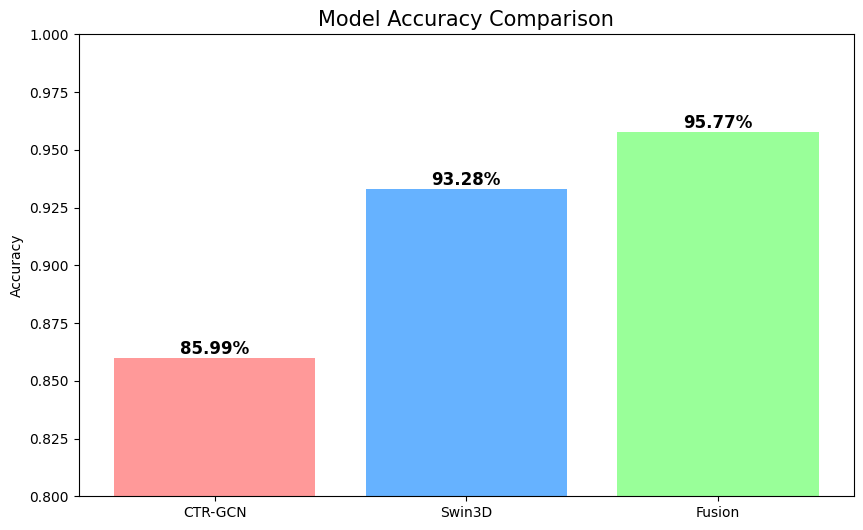

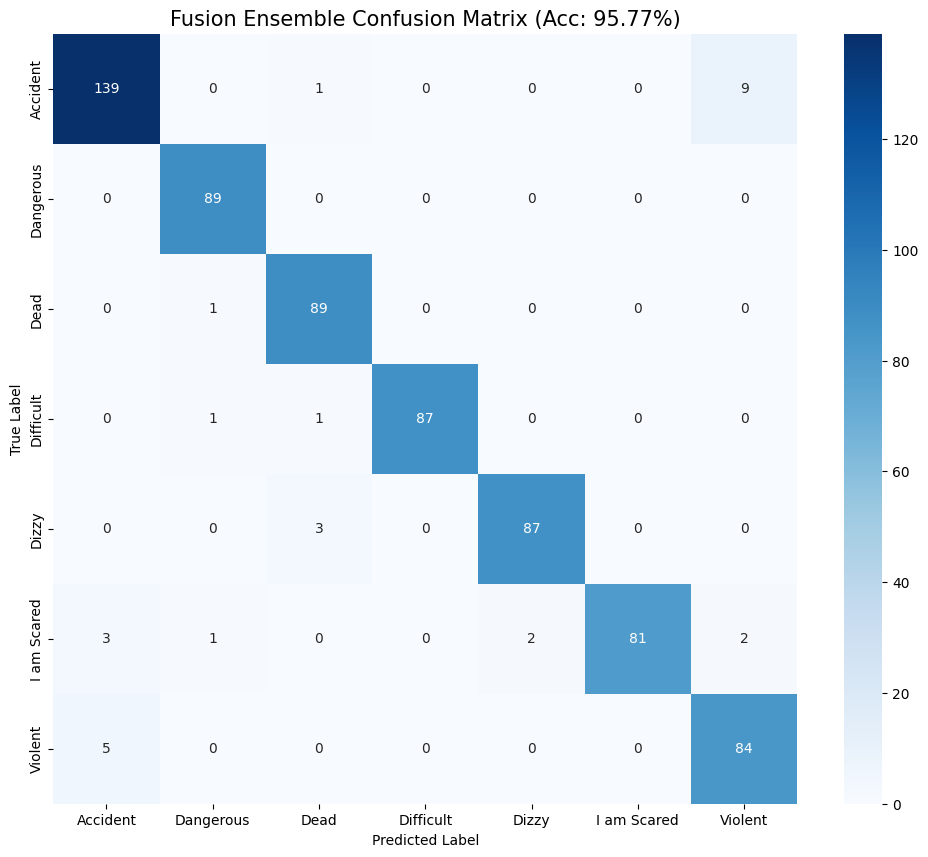


Fusion Classification Report:
              precision    recall  f1-score   support

    Accident       0.95      0.93      0.94       149
   Dangerous       0.97      1.00      0.98        89
        Dead       0.95      0.99      0.97        90
   Difficult       1.00      0.98      0.99        89
       Dizzy       0.98      0.97      0.97        90
 I am Scared       1.00      0.91      0.95        89
     Violent       0.88      0.94      0.91        89

    accuracy                           0.96       685
   macro avg       0.96      0.96      0.96       685
weighted avg       0.96      0.96      0.96       685



In [ ]:

# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SWIN_PATH = "/mnt/e/SignProject/SLR-Transformer/best_slr_swin_finetuned.pth"
GCN_PATH = "/mnt/e/SignProject/Skeleton based/best_ctr_gcn.pth"
RGB_ROOT = '/mnt/e/SignProject/R(2+1)D /R(2+1)D/frames_r21d'
SKELETON_ROOT = '/mnt/e/SignProject/Skeleton based/skeletons'
BATCH_SIZE = 1 # Keep 1 for accurate fusion analysis

# =============================================================================
# 1. MODEL DEFINITIONS (Must be included to load weights)
# =============================================================================

# --- CTR-GCN ---
class Graph:
    def __init__(self, strategy='spatial'):
        self.num_node = 33
        self.get_edge()
        self.A = self.get_adjacency_matrix()
    def get_edge(self):
        self.num_node = 33
        self_link = [(i, i) for i in range(self.num_node)]
        neighbor_link = [(0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8), (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), (17, 19), (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20), (11, 23), (12, 24), (23, 24), (23, 25), (24, 26), (25, 27), (26, 28), (27, 29), (28, 30), (29, 31), (30, 32), (27, 31), (28, 32)]
        self.edge = self_link + neighbor_link
        self.center = 0
    def get_adjacency_matrix(self):
        A = np.zeros((self.num_node, self.num_node))
        for i, j in self.edge: A[j, i] = 1; A[i, j] = 1
        Dl = np.sum(A, 0)
        Dn = np.zeros((self.num_node, self.num_node))
        for i in range(self.num_node): 
            if Dl[i] > 0: Dn[i, i] = Dl[i]**(-0.5)
        return torch.tensor(np.dot(np.dot(Dn, A), Dn), dtype=torch.float32)

class CTRGC(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(CTRGC, self).__init__()
        self.in_channels, self.out_channels = in_channels, out_channels
        self.rel_channels = 8 if in_channels <= 16 else in_channels // 8
        self.conv1 = nn.Conv2d(in_channels, self.rel_channels, kernel_size=1)
        self.conv2 = nn.Conv2d(in_channels, self.rel_channels, kernel_size=1)
        self.conv3 = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.conv4 = nn.Conv2d(self.rel_channels, out_channels, kernel_size=1)
        self.tanh = nn.Tanh()
    def forward(self, x, A):
        N, C, T, V = x.size()
        x1, x2 = self.conv1(x).mean(-2), self.conv2(x).mean(-2)
        x1 = self.tanh(x1.unsqueeze(-1) - x2.unsqueeze(-2))
        x1 = self.conv4(x1).permute(0, 2, 3, 1).contiguous()
        x3 = self.conv3(x).permute(0, 3, 2, 1).contiguous().view(N, V, T*self.out_channels)
        out = torch.matmul(A.to(x.device), x3).view(N, V, T, self.out_channels).permute(0, 3, 2, 1)
        return out + x3.view(N, V, T, self.out_channels).permute(0, 3, 2, 1)

class Block(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(Block, self).__init__()
        self.gcn = CTRGC(in_channels, out_channels)
        self.tcn = nn.Sequential(nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True), nn.Conv2d(out_channels, out_channels, kernel_size=(9,1), padding=(4,0), stride=(stride,1)), nn.BatchNorm2d(out_channels), nn.Dropout(0.1, inplace=True))
        self.residual = nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride,1)), nn.BatchNorm2d(out_channels)) if stride != 1 or in_channels != out_channels else lambda x: x
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x, A): return self.relu(self.tcn(self.gcn(x, A)) + self.residual(x))

class CTRGCN(nn.Module):
    def __init__(self, num_class):
        super(CTRGCN, self).__init__()
        self.graph = Graph()
        self.register_buffer('A', self.graph.A)
        self.data_bn = nn.BatchNorm1d(3 * 33)
        self.l1 = Block(3, 64)
        self.l2 = Block(64, 64)
        self.l3 = Block(64, 64)
        self.l4 = Block(64, 128, stride=2)
        self.l5 = Block(128, 128)
        self.l6 = Block(128, 128)
        self.l7 = Block(128, 256, stride=2)
        self.l8 = Block(256, 256)
        self.l9 = Block(256, 256)
        self.l10 = Block(256, 256)
        self.fc = nn.Linear(256, num_class)
    def forward(self, x):
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous().view(N, M*V*C, T)
        x = self.data_bn(x).view(N, M, V, C, T).permute(0, 1, 3, 4, 2).contiguous().view(N*M, C, T, V)
        for layer in [self.l1, self.l2, self.l3, self.l4, self.l5, self.l6, self.l7, self.l8, self.l9, self.l10]: x = layer(x, self.A)
        return self.fc(x.view(N, M, 256, -1, V).mean(4).mean(3).mean(1))

# --- DATASETS ---
class VideoDataset(Dataset):
    def __init__(self, root, split='val'):
        self.files = []
        cls_dir = os.path.join(root, split)
        self.classes = sorted(os.listdir(cls_dir))
        self.cls_map = {c: i for i, c in enumerate(self.classes)}
        for c in self.classes:
            for f in sorted(glob.glob(os.path.join(cls_dir, c, "*.jpg"))): # Finds frames, we assume folder structure
                # We need video folders, not frames. 
                pass 
            # Correct logic: List VIDEO folders
            vid_folders = sorted(os.listdir(os.path.join(cls_dir, c)))
            for vid in vid_folders:
                self.files.append((os.path.join(cls_dir, c, vid), self.cls_map[c]))
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        path, label = self.files[i]
        frames = sorted(glob.glob(os.path.join(path, "*.jpg")))
        if not frames: return torch.zeros(3, 32, 224, 224), label
        
        # Center Crop Time
        if len(frames) > 32:
            start = (len(frames) - 32) // 2
            frames = frames[start:start+32]
        else:
            frames = frames * (32 // len(frames) + 1)
            frames = frames[:32]
            
        imgs = []
        for f in frames:
            try: imgs.append(TF.to_tensor(TF.resize(Image.open(f).convert('RGB'), (224, 224))))
            except: continue
        if not imgs: return torch.zeros(3, 32, 224, 224), label
        
        # Normalize
        imgs = [TF.normalize(img, mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216]) for img in imgs]
        return torch.stack(imgs).permute(1, 0, 2, 3), label

class SkeletonDataset(Dataset):
    def __init__(self, root, split='val'):
        self.files = []
        cls_dir = os.path.join(root, split)
        self.classes = sorted(os.listdir(cls_dir))
        self.cls_map = {c: i for i, c in enumerate(self.classes)}
        for c in self.classes:
            for f in sorted(glob.glob(os.path.join(cls_dir, c, "*.npy"))):
                self.files.append((f, self.cls_map[c]))
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        path, label = self.files[i]
        data = np.load(path).transpose(2, 0, 1) # (T,V,C) -> (C,T,V)
        return torch.tensor(np.expand_dims(data, -1), dtype=torch.float32), label

# =============================================================================
# 2. MAIN VISUALIZATION LOOP
# =============================================================================

def main():
    # 1. Init Data
    print("Loading Data...")
    rgb_set = VideoDataset(RGB_ROOT, split='val')
    skel_set = SkeletonDataset(SKELETON_ROOT, split='val')
    
    # Verify Alignment
    if len(rgb_set) != len(skel_set):
        print(f"[WARNING] Dataset size mismatch! RGB: {len(rgb_set)}, Skel: {len(skel_set)}")
        print("Using the smaller size for safety.")
        length = min(len(rgb_set), len(skel_set))
    else:
        length = len(rgb_set)
        
    rgb_loader = DataLoader(rgb_set, batch_size=1, shuffle=False)
    skel_loader = DataLoader(skel_set, batch_size=1, shuffle=False)
    classes = rgb_set.classes

    # 2. Init Models
    print("Loading Models...")
    swin = models.video.swin3d_t()
    swin.head = nn.Sequential(nn.Dropout(0.5), nn.Linear(swin.head.in_features, len(classes)))
    swin.load_state_dict(torch.load(SWIN_PATH, map_location=DEVICE))
    swin.to(DEVICE).eval()

    gcn = CTRGCN(num_class=len(classes))
    gcn.load_state_dict(torch.load(GCN_PATH, map_location=DEVICE))
    gcn.to(DEVICE).eval()

    # 3. Inference
    print("Collecting Predictions...")
    y_true, y_swin, y_gcn, y_fuse = [], [], [], []

    with torch.no_grad():
        for (rx, ry), (sx, sy) in tqdm(zip(rgb_loader, skel_loader), total=length):
            if ry != sy: continue # Skip misaligned data
            
            rx, sx = rx.to(DEVICE), sx.to(DEVICE)
            
            # Forward
            out_swin = swin(rx)
            out_gcn = gcn(sx)
            out_fuse = (0.6 * out_swin) + (0.4 * out_gcn)
            
            y_true.append(ry.item())
            y_swin.append(torch.argmax(out_swin, 1).item())
            y_gcn.append(torch.argmax(out_gcn, 1).item())
            y_fuse.append(torch.argmax(out_fuse, 1).item())

    # 4. PLOT 1: Accuracy Bar Chart
    acc_swin = accuracy_score(y_true, y_swin)
    acc_gcn = accuracy_score(y_true, y_gcn)
    acc_fuse = accuracy_score(y_true, y_fuse)
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(['CTR-GCN', 'Swin3D', 'Fusion'], [acc_gcn, acc_swin, acc_fuse], 
            color=['#FF9999', '#66B2FF', '#99FF99'])
    plt.ylim(0.8, 1.0)
    plt.title('Model Accuracy Comparison', fontsize=15)
    plt.ylabel('Accuracy')
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height*100:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.savefig('accuracy_comparison.png')
    plt.show()
    
    # 5. PLOT 2: Fusion Confusion Matrix
    cm = confusion_matrix(y_true, y_fuse)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Fusion Ensemble Confusion Matrix (Acc: {acc_fuse*100:.2f}%)', fontsize=15)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('fusion_confusion_matrix.png')
    plt.show()
    
    print("\nFusion Classification Report:")
    print(classification_report(y_true, y_fuse, target_names=classes))

if __name__ == "__main__":
    main()

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import torchvision.transforms.functional as TF
import cv2
import mediapipe as mp
import numpy as np
from PIL import Image
import os

# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SWIN_PATH = "best_slr_swin.pth"
GCN_PATH = "best_ctr_gcn.pth"
VIDEO_PATH = "test_video.mp4" # <--- INPUT VIDEO
CLIP_LEN = 32
IMG_SIZE = 224
# Define classes manually or load from folder
CLASSES = ['Accident', 'Dangerous', 'Dead', 'Difficult', 'Dizzy', 'I am Scared', 'Violent']

# ==========================================
# 1. MODEL DEFINITIONS (Must match training)
# ==========================================

# --- GCN Definition ---
class Graph:
    def __init__(self, strategy='spatial'):
        self.num_node = 33
        self_link = [(i, i) for i in range(self.num_node)]
        neighbor_link = [
            (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8), 
            (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), 
            (17, 19), (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20), 
            (11, 23), (12, 24), (23, 24), (23, 25), (24, 26), (25, 27), (26, 28), 
            (27, 29), (28, 30), (29, 31), (30, 32), (27, 31), (28, 32)
        ]
        self.edge = self_link + neighbor_link
        self.center = 0
        self.A = self.get_adjacency_matrix()

    def get_adjacency_matrix(self):
        A = np.zeros((self.num_node, self.num_node))
        for i, j in self.edge:
            A[j, i] = 1
            A[i, j] = 1
        Dl = np.sum(A, 0)
        num_node = A.shape[0]
        Dn = np.zeros((num_node, num_node))
        for i in range(num_node):
            if Dl[i] > 0: Dn[i, i] = Dl[i]**(-0.5)
        DAD = np.dot(np.dot(Dn, A), Dn)
        return torch.tensor(DAD, dtype=torch.float32)

class CTRGC(nn.Module):
    def __init__(self, in_channels, out_channels, rel_reduction=8):
        super(CTRGC, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        if in_channels <= 16: self.rel_channels = 8
        else: self.rel_channels = in_channels // rel_reduction
        self.conv1 = nn.Conv2d(self.in_channels, self.rel_channels, kernel_size=1)
        self.conv2 = nn.Conv2d(self.in_channels, self.rel_channels, kernel_size=1)
        self.conv3 = nn.Conv2d(self.in_channels, self.out_channels, kernel_size=1)
        self.conv4 = nn.Conv2d(self.rel_channels, self.out_channels, kernel_size=1)
        self.tanh = nn.Tanh()

    def forward(self, x, A):
        N, C, T, V = x.size()
        x1 = self.conv1(x).mean(-2)
        x2 = self.conv2(x).mean(-2)
        x1 = self.tanh(x1.unsqueeze(-1) - x2.unsqueeze(-2))
        x1 = self.conv4(x1).permute(0, 2, 3, 1).contiguous()
        x3 = self.conv3(x)
        x3 = x3.permute(0, 3, 2, 1).contiguous().view(N, V, T*self.out_channels)
        out = torch.matmul(A.to(x.device), x3)
        out = out.view(N, V, T, self.out_channels).permute(0, 3, 2, 1)
        out = out + x3.view(N, V, T, self.out_channels).permute(0, 3, 2, 1)
        return out

class Block(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, residual=True):
        super(Block, self).__init__()
        self.gcn = CTRGC(in_channels, out_channels)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=(9,1), padding=(4,0), stride=(stride,1)),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(0.1, inplace=True)
        )
        if not residual: self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1): self.residual = lambda x: x
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride,1)),
                nn.BatchNorm2d(out_channels)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, A):
        res = self.residual(x)
        x = self.gcn(x, A)
        x = self.tcn(x)
        return self.relu(x + res)

class CTRGCN(nn.Module):
    def __init__(self, num_class, in_channels=3):
        super(CTRGCN, self).__init__()
        self.graph = Graph()
        A = self.graph.A
        self.register_buffer('A', A)
        self.data_bn = nn.BatchNorm1d(in_channels * 33)
        self.l1 = Block(3, 64, stride=1)
        self.l2 = Block(64, 64, stride=1)
        self.l3 = Block(64, 64, stride=1)
        self.l4 = Block(64, 128, stride=2)
        self.l5 = Block(128, 128, stride=1)
        self.l6 = Block(128, 128, stride=1)
        self.l7 = Block(128, 256, stride=2)
        self.l8 = Block(256, 256, stride=1)
        self.l9 = Block(256, 256, stride=1)
        self.l10 = Block(256, 256, stride=1)
        self.fc = nn.Linear(256, num_class)

    def forward(self, x):
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous().view(N, M*V*C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T).permute(0, 1, 3, 4, 2).contiguous().view(N * M, C, T, V)
        x = self.l1(x, self.A)
        x = self.l2(x, self.A)
        x = self.l3(x, self.A)
        x = self.l4(x, self.A)
        x = self.l5(x, self.A)
        x = self.l6(x, self.A)
        x = self.l7(x, self.A)
        x = self.l8(x, self.A)
        x = self.l9(x, self.A)
        x = self.l10(x, self.A)
        x = x.view(N, M, 256, -1, V).mean(4).mean(3)
        x = x.mean(1)
        return self.fc(x)

# ==========================================
# 2. PROCESSING PIPELINE
# ==========================================

def load_models():
    print("Loading Swin3D...")
    swin = models.video.swin3d_t()
    swin.head = nn.Sequential(nn.Dropout(0.5), nn.Linear(swin.head.in_features, len(CLASSES)))
    swin.load_state_dict(torch.load(SWIN_PATH, map_location=DEVICE))
    swin.to(DEVICE).eval()

    print("Loading CTR-GCN...")
    gcn = CTRGCN(num_class=len(CLASSES))
    gcn.load_state_dict(torch.load(GCN_PATH, map_location=DEVICE))
    gcn.to(DEVICE).eval()
    
    return swin, gcn

def process_video(path):
    print(f"Processing {path}...")
    cap = cv2.VideoCapture(path)
    mp_pose = mediapipe.solutions.pose
    pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5)
    
    frames_rgb = []
    frames_skel = []
    
    while True:
        ret, frame = cap.read()
        if not ret: break
        
        # 1. RGB Processing
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames_rgb.append(Image.fromarray(rgb))
        
        # 2. Skeleton Processing
        results = pose.process(rgb)
        frame_joints = []
        if results.pose_landmarks:
            for lm in results.pose_landmarks.landmark:
                frame_joints.append([lm.x, lm.y, lm.z])
        else:
            frame_joints = np.zeros((33, 3))
        frames_skel.append(frame_joints)
        
    cap.release()
    
    if len(frames_rgb) == 0: return None, None

    # Temporal Sampling (Center Crop to 32 frames)
    total_frames = len(frames_rgb)
    if total_frames < CLIP_LEN:
        # Loop padding
        frames_rgb = frames_rgb * (CLIP_LEN // total_frames + 1)
        frames_skel = frames_skel * (CLIP_LEN // total_frames + 1)
        frames_rgb = frames_rgb[:CLIP_LEN]
        frames_skel = frames_skel[:CLIP_LEN]
    else:
        # Center crop
        start = (total_frames - CLIP_LEN) // 2
        frames_rgb = frames_rgb[start : start + CLIP_LEN]
        frames_skel = frames_skel[start : start + CLIP_LEN]

    # --- Prepare Swin Input (1, 3, 32, 224, 224) ---
    rgb_tensors = []
    for img in frames_rgb:
        img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216])
        rgb_tensors.append(img)
    swin_input = torch.stack(rgb_tensors).permute(1, 0, 2, 3).unsqueeze(0)

    # --- Prepare GCN Input (1, 3, 32, 33, 1) ---
    skel_array = np.array(frames_skel, dtype=np.float32) # (32, 33, 3)
    skel_array = skel_array.transpose(2, 0, 1) # (3, 32, 33)
    skel_array = np.expand_dims(skel_array, axis=-1) # (3, 32, 33, 1)
    gcn_input = torch.tensor(skel_array).unsqueeze(0) # (1, 3, 32, 33, 1)

    return swin_input, gcn_input

def predict():
    if not os.path.exists(VIDEO_PATH):
        print("Video not found.")
        return

    import mediapipe # Lazy import check
    
    swin_model, gcn_model = load_models()
    swin_in, gcn_in = process_video(VIDEO_PATH)
    
    if swin_in is None:
        print("Failed to process video.")
        return

    swin_in = swin_in.to(DEVICE)
    gcn_in = gcn_in.to(DEVICE)

    with torch.no_grad():
        # Get Logits
        logits_swin = swin_model(swin_in)
        logits_gcn = gcn_model(gcn_in)
        
        # Softmax to get probabilities
        probs_swin = torch.softmax(logits_swin, dim=1)
        probs_gcn = torch.softmax(logits_gcn, dim=1)
        
        # FUSION
        probs_fuse = (0.6 * probs_swin) + (0.4 * probs_gcn)
        
        score, idx = torch.max(probs_fuse, 1)
        print("\n" + "="*40)
        print(f"FINAL PREDICTION: {CLASSES[idx.item()]}")
        print(f"Confidence:       {score.item()*100:.2f}%")
        print("="*40)
        
        print("\nIndividual Model Confidence:")
        print(f"Swin3D:  {probs_swin[0][idx].item()*100:.2f}%")
        print(f"CTR-GCN: {probs_gcn[0][idx].item()*100:.2f}%")

if __name__ == "__main__":
    predict()